# BaseAttentive: Quick Start Guide

This notebook demonstrates how to create and configure a BaseAttentive model.

## What is BaseAttentive?

BaseAttentive is a foundational blueprint for building powerful, data-driven, sequence-to-sequence time series forecasting models with advanced attention mechanisms.

### Key Features
- **Flexible Architecture**: Hybrid (LSTM+Attention) or Pure Transformer
- **Multiple Attention Types**: Cross, Hierarchical, Memory-Augmented
- **Feature Selection**: Variable Selection Networks (VSN) for learnable feature importance
- **Uncertainty Quantification**: Quantile-based forecasting for confidence intervals
- **Dynamic Time Warping**: Automatic temporal alignment

## Step 1: Installation

```bash
pip install base-attentive==2.2.0
```

Or for development:
```bash
git clone https://github.com/earthai-tech/base-attentive.git
cd base-attentive
pip install -e ".[dev]"
```

> **v2.2.0 note:** `BASE_ATTENTIVE_BACKEND` must be set before importing
> `base_attentive`. Run the **Backend Setup** cell above first.

In [1]:
# ── v2.2.0 Backend Setup ─────────────────────────────────────────────────────
# BASE_ATTENTIVE_BACKEND must be set *before* importing base_attentive.
# Choose your installed backend: "tensorflow" | "torch" | "jax" | "auto"
import os
os.environ.setdefault("BASE_ATTENTIVE_BACKEND", "tensorflow")
os.environ.setdefault("KERAS_BACKEND", os.environ["BASE_ATTENTIVE_BACKEND"])
import keras  # initialise Keras 3 backend before base_attentive
BACKEND = os.environ["BASE_ATTENTIVE_BACKEND"]
print(f"Backend: {BACKEND}")

Backend: tensorflow


In [2]:
# Import required libraries
import numpy as np

from base_attentive import BaseAttentive, __version__

print(f"BaseAttentive version: {__version__}")

BaseAttentive version: 2.2.0


## Step 2: Create a Basic Model

Define input dimensions and create a model instance.

In [3]:
# Define input dimensions
STATIC_DIM = (
    4  # e.g., location, altitude, climate zone, soil type
)
DYNAMIC_DIM = 8  # e.g., temperature, humidity, pressure, wind speed, etc
FUTURE_DIM = 6  # e.g., forecasted weather features
OUTPUT_DIM = 2  # e.g., target 1 and target 2
FORECAST_HORIZON = 24  # Predict 24 steps ahead

# Create model
model = BaseAttentive(
    static_input_dim=STATIC_DIM,
    dynamic_input_dim=DYNAMIC_DIM,
    future_input_dim=FUTURE_DIM,
    output_dim=OUTPUT_DIM,
    forecast_horizon=FORECAST_HORIZON,
    embed_dim=32,
    attention_units=64,
    num_heads=8,
    dropout_rate=0.15,
    name="BasicAttentiveModel",
)

print("✅ Model created successfully!")
print(model)

D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'static_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'static_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'dynamic_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'dynamic_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'future_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'future_dim' instead.
  resolved = resolve_deprecated_kwargs(


✅ Model created successfully!
<BaseAttentive name=BasicAttentiveModel, built=False>


## Step 3: Inspect Model Configuration

View the complete model configuration.

In [4]:
# Get full configuration
config = model.get_config()

print("\n📋 Model Configuration:")
print("=" * 50)
for key, value in config.items():
    if value is not None:
        print(f"  {key:.<30} {value}")


📋 Model Configuration:
  static_dim.................... 4
  dynamic_dim................... 8
  future_dim.................... 6
  output_dim.................... 2
  forecast_horizon.............. 24
  num_encoder_layers............ 2
  embed_dim..................... 32
  hidden_units.................. 64
  lstm_units.................... 64
  attention_units............... 64
  num_heads..................... 8
  dropout_rate.................. 0.15
  lookback_window............... 10
  memory_size................... 100
  multi_scale_agg............... last
  final_agg..................... last
  activation.................... relu
  use_residuals................. True
  use_vsn....................... True
  use_batch_norm................ False
  apply_dtw..................... True
  objective..................... hybrid
  architecture_config........... {}
  component_overrides........... {}
  verbose....................... 0
  name.......................... BasicAttentiveModel


## Step 4: Create Example Data

Generate synthetic data to demonstrate the model structure.

In [5]:
# Generate sample data
BATCH_SIZE = 32
TIME_STEPS = 10  # Historical lookback window

# Static features: (batch_size, static_dim)
static_features = np.random.randn(
    BATCH_SIZE, STATIC_DIM
).astype("float32")

# Dynamic features: (batch_size, time_steps, dynamic_dim)
dynamic_features = np.random.randn(
    BATCH_SIZE, TIME_STEPS, DYNAMIC_DIM
).astype("float32")

# Future features: (batch_size, forecast_horizon, future_dim)
future_features = np.random.randn(
    BATCH_SIZE, FORECAST_HORIZON, FUTURE_DIM
).astype("float32")

print("\n📊 Sample Data Shapes:")
print(f"  Static:  {static_features.shape}")
print(f"  Dynamic: {dynamic_features.shape}")
print(f"  Future:  {future_features.shape}")


📊 Sample Data Shapes:
  Static:  (32, 4)
  Dynamic: (32, 10, 8)
  Future:  (32, 24, 6)


## Step 5: Model Summary

Display model hyperparameters and settings.

In [6]:
# Display model summary
print("\n📈 Model Summary:")
print("=" * 50)

summary_info = {
    "Architecture": model.objective,
    "Mode": model.mode,
    "Encoder Layers": model.num_encoder_layers,
    "Attention Heads": model.num_heads,
    "Dropout Rate": model.dropout_rate,
    "Use Residuals": model.use_residuals,
    "Use VSN": model.use_vsn,
    "Apply DTW": model.apply_dtw,
}

for key, value in summary_info.items():
    print(f"  {key:.<25} {value}")


📈 Model Summary:
  Architecture............. hybrid
  Mode..................... None
  Encoder Layers........... 2
  Attention Heads.......... 8
  Dropout Rate............. 0.15
  Use Residuals............ True
  Use VSN.................. True
  Apply DTW................ True


## Step 6: Save/Load Model Configuration

Demonstrate configuration serialization.

In [7]:
# Save configuration
import json

config = model.get_config()

# Convert to JSON-serializable format
json_config = json.dumps(
    {
        k: str(v)
        if not isinstance(v, (int, float, bool, type(None)))
        else v
        for k, v in config.items()
    },
    indent=2,
)

print("\n💾 Saved Configuration (JSON snippet):")
print(json_config[:500] + "...")

# Later, recreate model from config
model2 = BaseAttentive.from_config(config)
print("\n✅ Model recreated from configuration")


💾 Saved Configuration (JSON snippet):
{
  "static_dim": 4,
  "dynamic_dim": 8,
  "future_dim": 6,
  "output_dim": 2,
  "forecast_horizon": 24,
  "mode": null,
  "num_encoder_layers": 2,
  "quantiles": null,
  "embed_dim": 32,
  "hidden_units": 64,
  "lstm_units": 64,
  "attention_units": 64,
  "num_heads": 8,
  "dropout_rate": 0.15,
  "lookback_window": 10,
  "memory_size": 100,
  "scales": null,
  "multi_scale_agg": "last",
  "final_agg": "last",
  "activation": "relu",
  "use_residuals": true,
  "use_vsn": true,
  "vsn_units": nul...

✅ Model recreated from configuration


## Step 5: Train the Model

Compile and fit the model on our synthetic data for a quick demonstration.

In [8]:
import keras

# Use a small, quick-to-train setup
BATCH_SIZE = 32
TIME_STEPS = 10

# Regenerate data with consistent seed
np.random.seed(42)
static_data  = np.random.randn(BATCH_SIZE, STATIC_DIM).astype('float32')
dynamic_data = np.random.randn(BATCH_SIZE, TIME_STEPS, DYNAMIC_DIM).astype('float32')
future_data  = np.random.randn(BATCH_SIZE, FORECAST_HORIZON, FUTURE_DIM).astype('float32')

# Synthetic target: sine wave per sample + noise
t = np.linspace(0, 2 * np.pi, FORECAST_HORIZON)
target = (np.sin(t)[None, :, None] * np.random.rand(BATCH_SIZE, 1, OUTPUT_DIM)
          + 0.1 * np.random.randn(BATCH_SIZE, FORECAST_HORIZON, OUTPUT_DIM)).astype('float32')

_ = model([static_data, dynamic_data, future_data])  # build weights
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

history = model.fit(
    [static_data, dynamic_data, future_data],
    target,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
)

print()
print(f'Final train MSE: {history.history["loss"][-1]:.4f}')
print(f'Final val   MSE: {history.history["val_loss"][-1]:.4f}')

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.8540 - mae: 0.7169 - val_loss: 0.1792 - val_mae: 0.3470
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.2138 - mae: 0.3689 - val_loss: 0.1308 - val_mae: 0.2854
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1521 - mae: 0.3033 - val_loss: 0.1196 - val_mae: 0.2704
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1419 - mae: 0.2939 - val_loss: 0.1062 - val_mae: 0.2599
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.1326 - mae: 0.2875 - val_loss: 0.1019 - val_mae: 0.2569
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1301 - mae: 0.2881 - val_loss: 0.0971 - val_mae: 0.2482
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1264 - mae: 0.2810 - val_loss: 0.0958 - val_mae: 0.2448
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1229 - mae: 0.2737 - val_loss: 0.0897 - val_mae: 0.2386
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1183 - mae: 0.

## Step 6: Visualize Training History

Plot the training and validation loss curves.

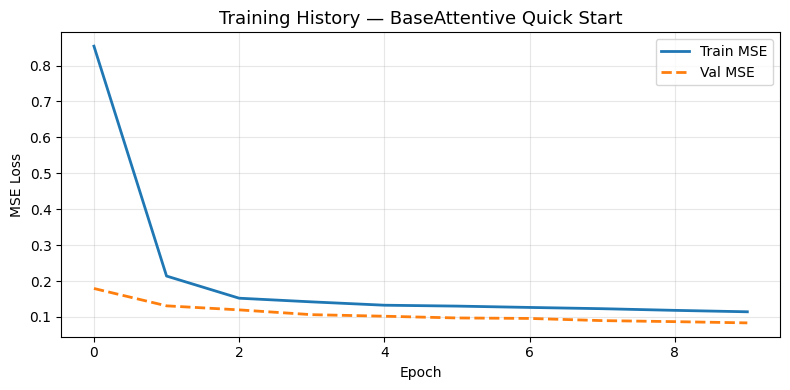

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Train MSE', linewidth=2)
ax.plot(history.history['val_loss'], label='Val MSE',   linewidth=2, linestyle='--')
ax.set_title('Training History — BaseAttentive Quick Start', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Forecast vs Actual

Compare model predictions against the synthetic targets for a single sample.

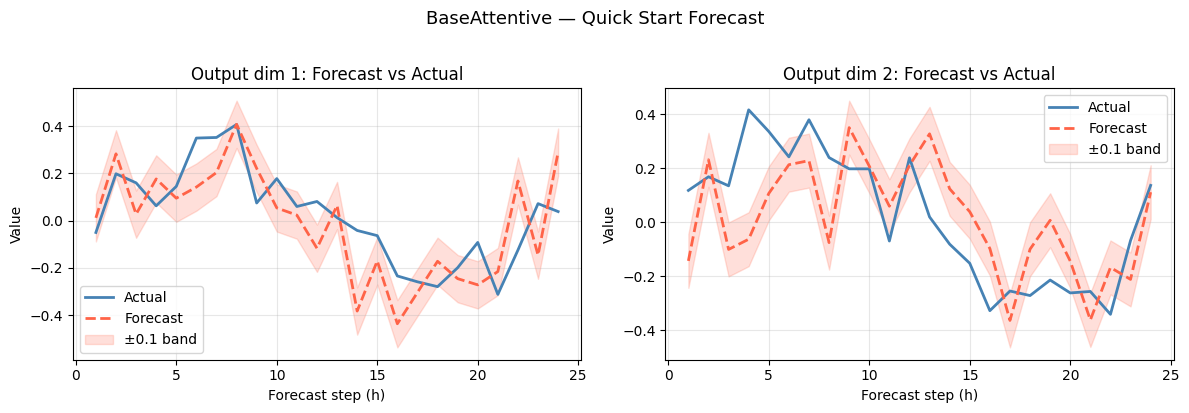

Sample MAE: 0.1528


In [10]:
# Predict on the full batch
preds = model.predict([static_data, dynamic_data, future_data], verbose=0)
# preds shape: (batch, forecast_horizon, output_dim)

sample_idx = 0
fig, axes = plt.subplots(1, OUTPUT_DIM, figsize=(6 * OUTPUT_DIM, 4), squeeze=False)

hours = np.arange(1, FORECAST_HORIZON + 1)
for d in range(OUTPUT_DIM):
    ax = axes[0][d]
    ax.plot(hours, target[sample_idx, :, d],  label='Actual',    linewidth=2,   color='steelblue')
    ax.plot(hours, preds[sample_idx,  :, d],  label='Forecast',  linewidth=2,   color='tomato', linestyle='--')
    ax.fill_between(hours,
                    preds[sample_idx, :, d] - 0.1,
                    preds[sample_idx, :, d] + 0.1,
                    alpha=0.2, color='tomato', label='±0.1 band')
    ax.set_title(f'Output dim {d + 1}: Forecast vs Actual', fontsize=12)
    ax.set_xlabel('Forecast step (h)')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('BaseAttentive — Quick Start Forecast', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

mae = float(np.mean(np.abs(preds[sample_idx] - target[sample_idx])))
print(f'Sample MAE: {mae:.4f}')

## What's Next?

Check out the other example notebooks:

1. **02_hybrid_vs_transformer.ipynb** - Compare hybrid and transformer encoder choices
2. **03_attention_stack_configuration.ipynb** - Configure the decoder attention stack
3. **04_standalone_applications.ipynb** - End-to-end forecasting examples across domains
4. **05_kernel_robust_networks.ipynb** - Use BaseAttentive as a reusable forecasting kernel
5. **06_crps_probabilistic_forecasting.ipynb** - Quantile, Gaussian, and mixture CRPS workflows
6. **07_v2_spec_registry.ipynb** - Declarative V2 specs, registries, and resolver assembly

## 📚 Resources

- [Full Documentation](https://github.com/earthai-tech/base-attentive)
- [GitHub Issues](https://github.com/earthai-tech/base-attentive/issues)
